<a href="https://colab.research.google.com/github/malikshahzaib263/neurofive-ml-track/blob/main/Titanic_EDA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Titanic Dataset - Exploratory Data Analysis (EDA)

**Name:** Shahzaib Arshad

**Task:** Neurofive ML Track - Task 1

**Dataset:** Titanic - Machine Learning from Disaster

In [1]:
from google.colab import files

uploaded = files.upload()

Saving train.csv to train.csv


In [2]:
import pandas as pd
import numpy as np

In [3]:
df = pd.read_csv("train.csv")

In [4]:
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [6]:
df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [7]:
df.shape

(891, 12)

In [8]:
df.isnull().sum()

,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,177
SibSp,0
Parch,0
Ticket,0
Fare,0


In [9]:
df.select_dtypes(include="number").columns

Index(['PassengerId', 'Survived', 'Pclass', 'Age', 'SibSp', 'Parch', 'Fare'], dtype='object')

In [10]:
df.select_dtypes(include="object").columns

Index(['Name', 'Sex', 'Ticket', 'Cabin', 'Embarked'], dtype='object')

## Data Story

The Titanic dataset contains 891 rows and 12 columns. It includes passenger information such as age, gender, ticket class, fare, and survival status. During the initial exploration, I found that the Age, Cabin, and Embarked columns contain missing values, with Cabin having the highest number of missing records. The dataset includes both numerical and categorical features, making it suitable for machine learning classification problems. This exploratory analysis helped me understand the dataset's structure and quality before moving to data preprocessing and model building.

In [11]:
print("Rows and Columns:", df.shape)

print("\nMissing Values:")
print(df.isnull().sum())

print("\nNumerical Columns:")
print(df.select_dtypes(include="number").columns.tolist())

print("\nCategorical Columns:")
print(df.select_dtypes(include="object").columns.tolist())

Rows and Columns: (891, 12)

Missing Values:
PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

Numerical Columns:
['PassengerId', 'Survived', 'Pclass', 'Age', 'SibSp', 'Parch', 'Fare']

Categorical Columns:
['Name', 'Sex', 'Ticket', 'Cabin', 'Embarked']


# Data Cleaning and Visualization

In this section, I cleaned the Titanic dataset by handling missing values and prepared it for analysis. After cleaning the data, I created different visualizations to better understand the distribution of features, detect outliers, and identify relationships between variables. These visualizations help reveal important patterns before building a machine learning model.

In [12]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

## Handling Missing Values

The dataset contains missing values in the Age, Cabin, and Embarked columns. Before creating visualizations, these missing values need to be handled to improve data quality and ensure accurate analysis.

In [13]:
# Fill missing Age values with the median
df["Age"] = df["Age"].fillna(df["Age"].median())

# Fill missing Embarked values with the mode
df["Embarked"] = df["Embarked"].fillna(df["Embarked"].mode()[0])

# Drop Cabin column because it contains too many missing values
df = df.drop(columns=["Cabin"])

# Check missing values again
df.isnull().sum()

,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,0
SibSp,0
Parch,0
Ticket,0
Fare,0


## Why did I choose this approach?

I filled the missing values in the **Age** column using the median because it is less affected by outliers than the mean. The **Embarked** column is categorical, so I filled its missing values using the mode, which represents the most common value. The **Cabin** column had too many missing values, so I removed it because it would not provide reliable information for analysis.

## Age Distribution (Histogram)

A histogram shows how the ages of passengers are distributed. It helps us understand whether most passengers were young, middle-aged, or older.

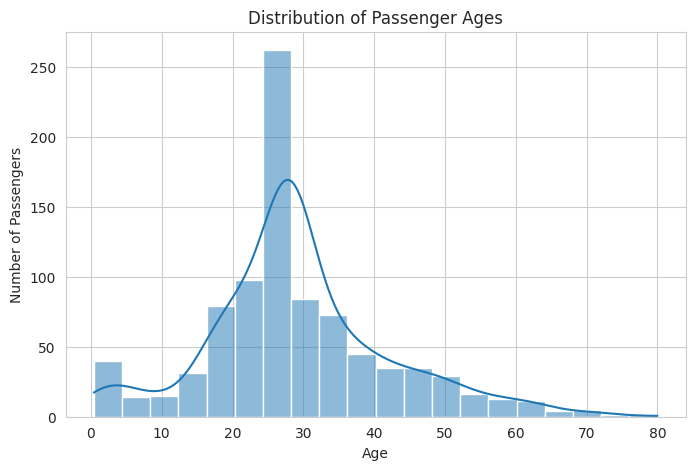

In [14]:
plt.figure(figsize=(8,5))

sns.histplot(df["Age"], bins=20, kde=True)

plt.title("Distribution of Passenger Ages")
plt.xlabel("Age")
plt.ylabel("Number of Passengers")

plt.show()

## Detecting Outliers Using a Boxplot

A boxplot helps identify outliers in the dataset. In this analysis, I used the Fare column to detect passengers who paid unusually high ticket prices.

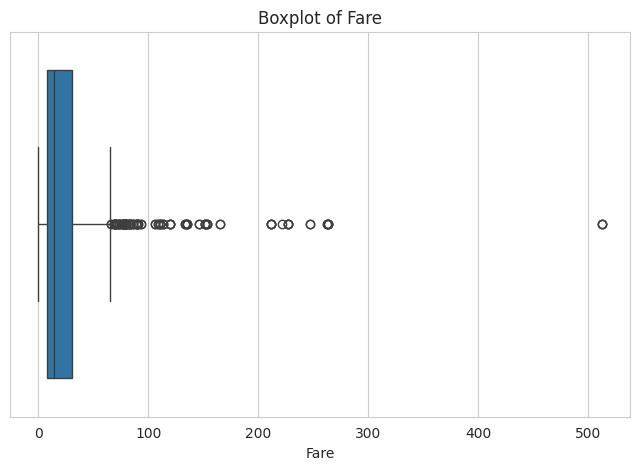

In [15]:
plt.figure(figsize=(8,5))

sns.boxplot(x=df["Fare"])

plt.title("Boxplot of Fare")

plt.show()

## Survival Count

This bar chart compares the number of passengers who survived with those who did not survive.

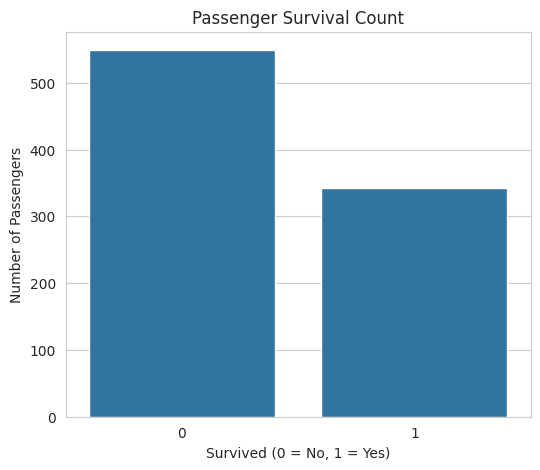

In [16]:
plt.figure(figsize=(6,5))

sns.countplot(x="Survived", data=df)

plt.title("Passenger Survival Count")
plt.xlabel("Survived (0 = No, 1 = Yes)")
plt.ylabel("Number of Passengers")

plt.show()

## Correlation Heatmap

The heatmap shows the correlation between numerical features in the dataset. It helps identify which variables have stronger relationships with each other.

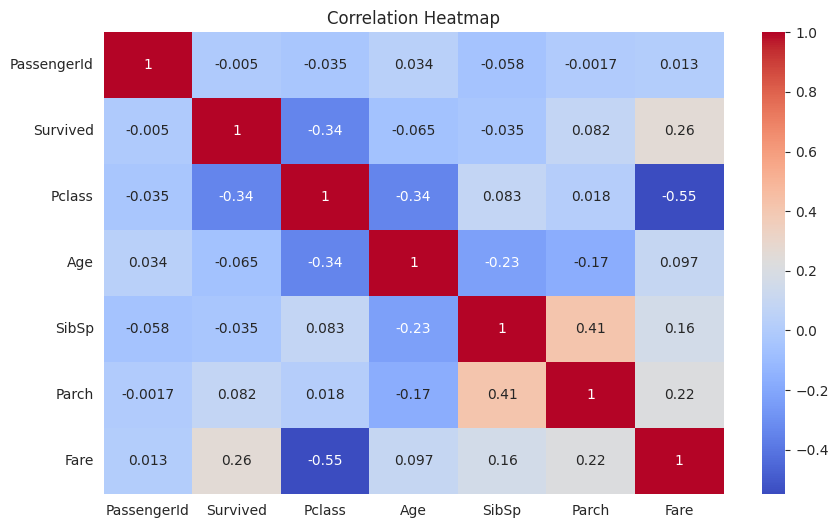

In [17]:
plt.figure(figsize=(10,6))

corr = df.select_dtypes(include="number").corr()

sns.heatmap(corr, annot=True, cmap="coolwarm")

plt.title("Correlation Heatmap")

plt.show()

## Which feature do you think most affects survival, and why?

Based on the analysis, I believe that **Sex** has the greatest impact on survival. Female passengers had a significantly higher survival rate than male passengers. In addition, passenger class (Pclass) also influenced survival, as first-class passengers generally had better chances of survival than passengers in lower classes.